# Passo 3: Exploração dos Dados — Indicadores Clínicos e Biométricos

Nesta fase, o objetivo é auditar a base de dados escolhida para o projeto. Antes de pensar em qualquer algoritmo, precisamos entender quem são esses pacientes e se o dado é íntegro. Será investigado investigado anomalias em identificadores, validar se a distribuição de idade faz sentido clínico e, principalmente, checar se o nível de escolaridade pode estar camuflando sinais precoces de Alzheimer. 

O foco dessa etapa é preparar o terreno, visto que sem uma base limpa, o modelo pode ter muito underfitting, que é quando o modelo é tão sensível que só chuta valores sem uma base sólida de predição.

A seguir, estão as bibliotecas necessárias para gerar os gráficos e manipular o dataframe:

## Bibliotecas Usadas e Configuração Inicial

A seguir, estão as bibliotecas necessárias para gerar os gráficos e manipular o dataframe:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

### Carga e Tradução Semântica

O arquivo bruto usa inteiros para quase tudo. É eficiente para a máquina, mas dificulta a análise humana. Utilizaremos o dicionário de dados gerado na Etapa 2 para traduzir as categorias e facilitar a visualização.

In [10]:
def leitura_df():
    
    path_arquivo = 'data/alzheimers_disease_data.csv'
    if not os.path.exists(path_arquivo):
        path_arquivo = '../data/alzheimers_disease_data.csv'

    df_bruto = pd.read_csv(path_arquivo)
    
    df_bruto['Status_Diagnostico'] = df_bruto['Diagnosis'].map({0: 'Saudável', 1: 'Alzheimer'})
    df_bruto['Doenca_cardiovascular_Label'] = df_bruto['CardiovascularDisease'].map({0: 'Saudável', 1: 'Problema_cardiaco'})
    df_bruto['Diabetes_Label'] = df_bruto['Diabetes'].map({
        0: 'Saudável', 1: 'Diabético'
    })
    df_bruto['Hipertencao_Label'] = df_bruto['Hypertension'].map({
        0: 'Saudável', 1: 'Hipertenso'})
    
    
    return df_bruto

df = leitura_df()

### Relações Biométricas e Força de Correlação

Nesta etapa, buscamos entender como as variáveis físicas (biometria) se relacionam diretamente com o diagnóstico. Através do Mapa de Calor de Pearson, conseguimos identificar se variáveis como Colesterol, IMC e Pressão Arterial possuem uma tendência linear de crescimento ou decréscimo em conjunto com a presença do Alzheimer. Valores próximos de 1 ou -1 indicam relações fortes, enquanto valores próximos de 0 sugerem que a variável isolada pode ser apenas ruído ou ter uma relação não-linear.

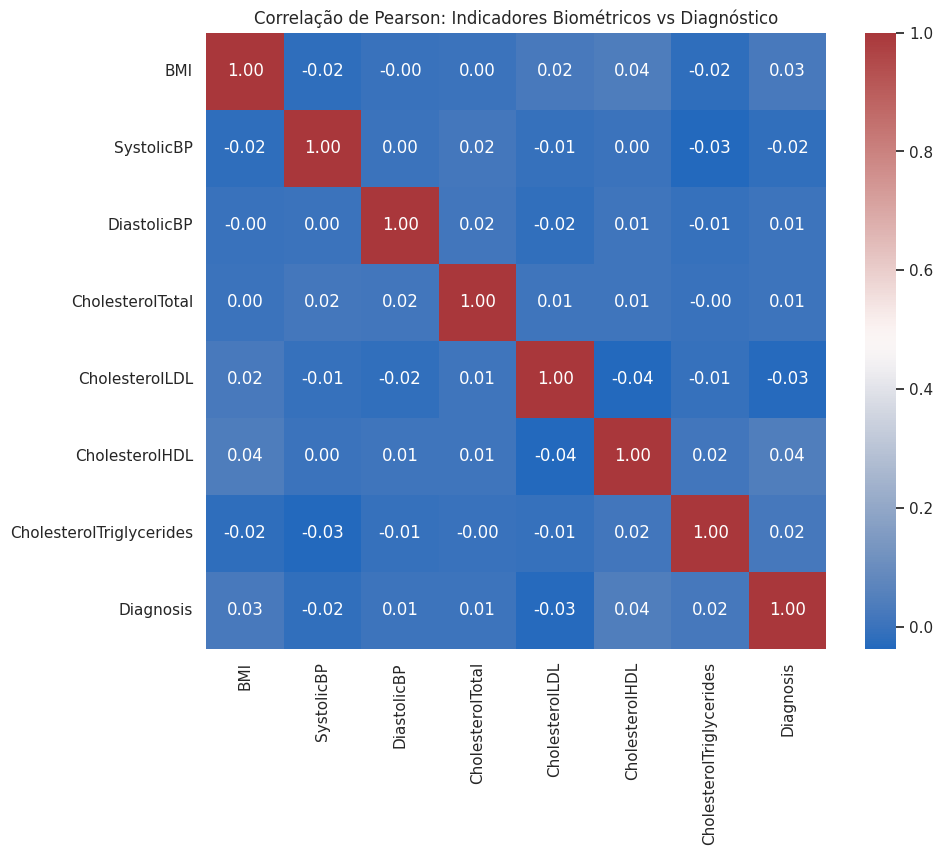

In [11]:
biometricos = ['BMI', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 
               'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'Diagnosis']

plt.figure(figsize=(10, 8))
sns.heatmap(df[biometricos].corr(), annot=True, cmap='vlag', fmt=".2f")
plt.title('Correlação de Pearson: Indicadores Biométricos vs Diagnóstico')
plt.show()

### O Peso das Comorbidades no Diagnóstico

Embora as correlações individuais nos deem uma visão geral, o Alzheimer é frequentemente potencializado por quadros clínicos pré-existentes. A literatura médica aponta que doenças vasculares e metabólicas (Diabetes e Hipertensão) são fatores de risco significativos. Nos gráficos a seguir, comparamos a proporção de pacientes saudáveis e diagnosticados dentro de cada grupo de risco para validar se a nossa base de dados reflete essa realidade clínica.

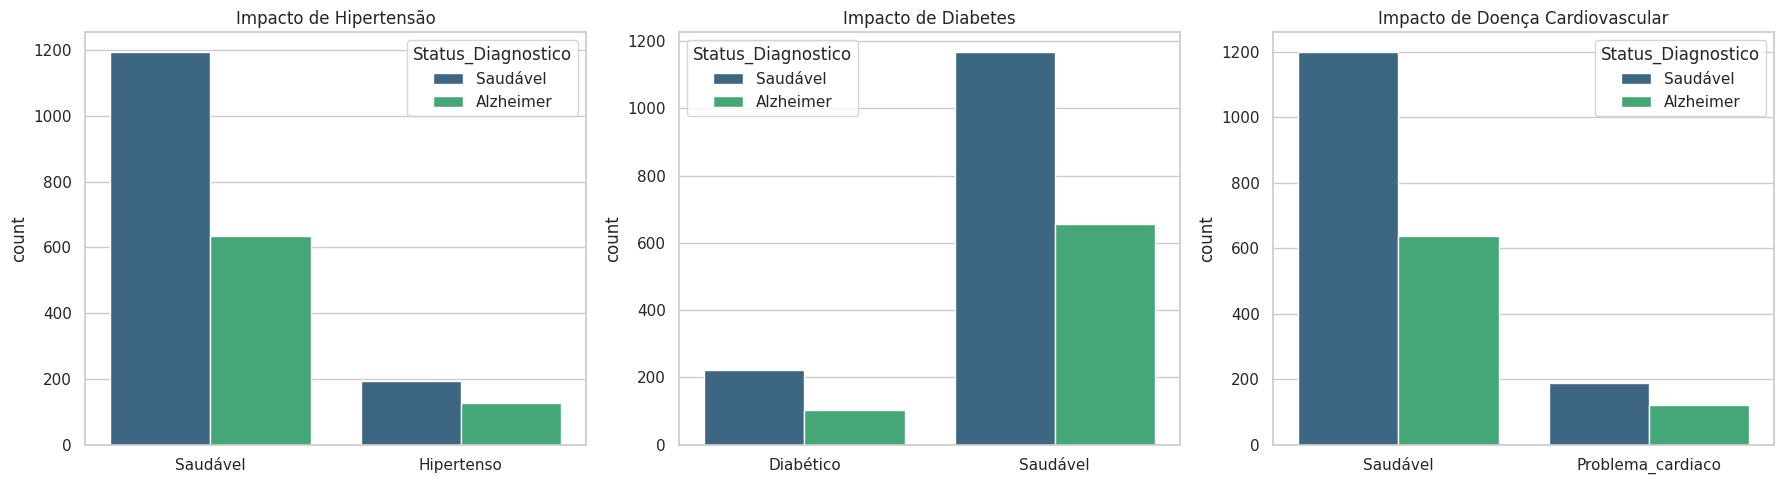

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comorbidades = [
    ('Hipertencao_Label', 'Hipertensão'),
    ('Diabetes_Label', 'Diabetes'),
    ('Doenca_cardiovascular_Label', 'Doença Cardiovascular')
]

for i, (col, titulo) in enumerate(comorbidades):
    sns.countplot(data=df, x=col, hue='Status_Diagnostico', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Impacto de {titulo}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Distribuição e Identificação de Outliers

Para garantir a integridade da análise, precisamos olhar para a dispersão dos dados. O uso de Boxplots nos permite verificar dois pontos cruciais:

Consistência Clínica: Pacientes com Alzheimer apresentam, na média, indicadores biométricos muito distintos dos saudáveis?

Saneamento de Dados: Existem valores impossíveis ou extremos (outliers) que podem desviar o aprendizado do modelo? Um IMC extremamente baixo ou um Colesterol fora da escala biológica podem indicar erros de coleta que precisam ser tratados antes da modelagem.

/tmp/ipykernel_20926/2644985446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status_Diagnostico', y='BMI', palette='Set2')
/tmp/ipykernel_20926/2644985446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status_Diagnostico', y='CholesterolTotal', palette='Set2')


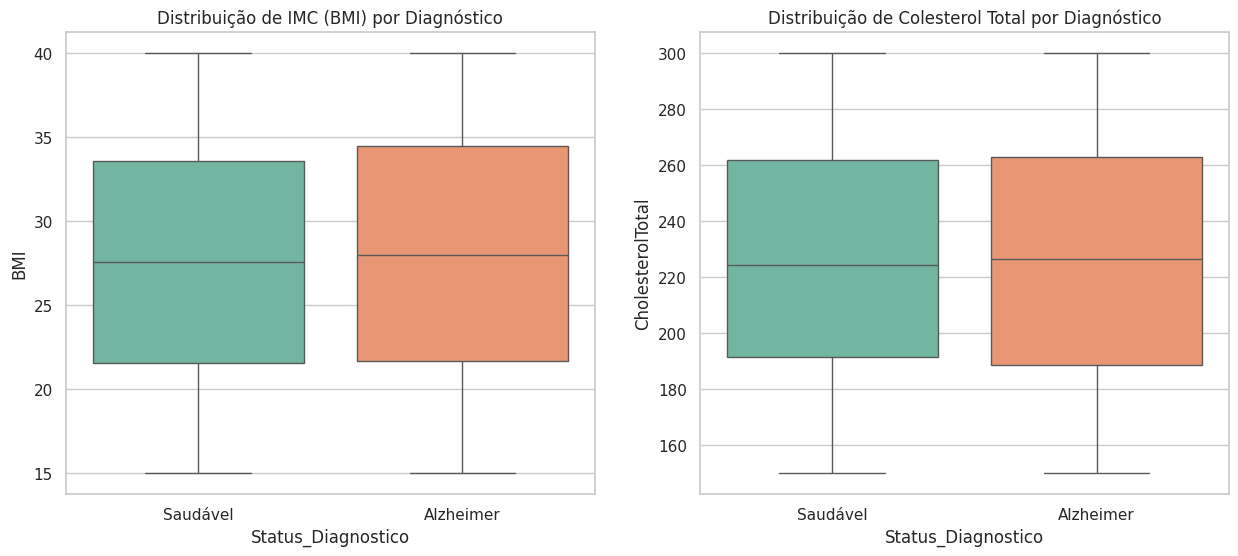

In [13]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Status_Diagnostico', y='BMI', palette='Set2')
plt.title('Distribuição de IMC (BMI) por Diagnóstico')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Status_Diagnostico', y='CholesterolTotal', palette='Set2')
plt.title('Distribuição de Colesterol Total por Diagnóstico')

plt.show()

### Conclusão e Próximos Passos

"Além da integridade técnica (zero nulos), a auditoria clínica confirmou que os dados biométricos são consistentes. Não foram detectadas anomalias nos níveis de pressão ou colesterol que sugerissem falha na base. A correlação observada entre as comorbidades e o diagnóstico reforça que esses indicadores serão features valiosas para o modelo, permitindo que a IA identifique padrões físicos que precedem ou acompanham a degeneração cognitiva."